### 🤖 What are Multi-Agent RAG Systems?
A Multi-Agent RAG System splits the RAG pipeline into multiple specialized agents — each responsible for a specific role — and enables them to collaborate on a single query or task.

#### 1. 📋 Multi-Agent Network RAG System with LangGraph
Project Overview

A beginner-friendly Retrieval-Augmented Generation (RAG) system that uses a multi-agent architecture to intelligently answer questions from your documents. Built with LangGraph v0.3 for workflow orchestration and OpenAI for language understanding.

What It Does

Transforms your documents (PDFs, text files) into a searchable knowledge base that can answer questions intelligently using AI. Simply upload documents and ask questions in natural language - the system finds relevant information and generates comprehensive answers.
Key Features

- 📚 Multi-Format Support: Handles PDF and text documents
- 🤖 3-Agent Architecture: Specialized agents for document processing, retrieval, and answer generation
- 🔍 Smart Search: Vector-based semantic search finds relevant information
- 💬 Natural Language Q&A: Ask questions in plain English


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm=init_chat_model("openai:gpt-4o-mini")
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000209BC7A5C70>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000209BCC5D910>, root_client=<openai.OpenAI object at 0x0000020985C04C50>, root_async_client=<openai.AsyncOpenAI object at 0x00000209BCA23F80>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [5]:
!pip install -U langchain-tavily

In [ ]:
# --- Imports ---
import os
from typing import List
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

In [25]:
# -----------------------------------------------
# 1. Document Preprocessing — Improved
# -----------------------------------------------

URLS = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
    "https://lilianweng.github.io/posts/2025-05-01-thinking/",
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2024-02-05-human-data-quality/",
    "https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/",
    "https://lilianweng.github.io/posts/2023-01-10-inference-optimization/",
    "https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/",
    "https://lilianweng.github.io/posts/2018-06-24-attention/",
    "https://lilianweng.github.io/posts/2019-01-31-lm/",
    "https://lilianweng.github.io/posts/2021-07-11-diffusion-models/",
    "https://lilianweng.github.io/posts/2018-08-12-vae/",
    "https://lilianweng.github.io/posts/2017-08-20-gan/",
    "https://lilianweng.github.io/posts/2018-10-13-flow-models/",
    "https://lilianweng.github.io/posts/2018-04-08-policy-gradient/",
    "https://lilianweng.github.io/posts/2018-02-19-rl-overview/",
    "https://lilianweng.github.io/posts/2021-03-21-lm-toxicity/",
    "https://lilianweng.github.io/posts/2021-01-02-controllable-text-generation/",
    "https://lilianweng.github.io/posts/2020-06-07-exploration-drl/",
    "https://lilianweng.github.io/posts/2021-05-31-contrastive/",
    "https://lilianweng.github.io/posts/2019-11-10-self-supervised/",
    "https://lilianweng.github.io/posts/2018-11-30-meta-learning/",
    "https://lilianweng.github.io/posts/2022-04-15-data-gen/",
    "https://lilianweng.github.io/posts/2022-02-20-active-learning/",
]

# -----------------------------------------------
# STEP 1: Load — Extract only the article body
# -----------------------------------------------
# FIX: Lilian Weng's blog has NO special CSS class on the article body.
# The content lives inside <article> or the main <div> under the <main> tag.
# SoupStrainer("article") correctly targets just the post content,
# skipping nav bars, footers, TOC, and sidebar menus entirely.

from langchain_community.document_loaders import WebBaseLoader
import bs4

def load_url(url: str):
    """Load a single URL, extracting only the article body."""
    loader = WebBaseLoader(
        web_paths=[url],
        bs_kwargs={
            "parse_only": bs4.SoupStrainer("article")  # ✅ matches actual HTML structure
        },
        requests_kwargs={
            "headers": {
                # Avoid being blocked by acting like a real browser
                "User-Agent": "Mozilla/5.0 (compatible; RAG-pipeline/1.0)"
            },
            "timeout": 15
        }
    )
    docs = loader.load()

    # Attach clean metadata to each doc for traceability in the vector store
    for doc in docs:
        doc.metadata["source_url"] = url
        doc.metadata["domain"] = "lilianweng.github.io"
        # Extract post title from URL slug (e.g. "2023-06-23-agent" → "agent")
        slug = url.rstrip("/").split("/")[-1]
        doc.metadata["post_slug"] = slug

    return docs

# Load all URLs with basic error handling so one bad URL doesn't crash everything
raw_docs = []
failed_urls = []

for url in URLS:
    try:
        docs = load_url(url)
        if docs and docs[0].page_content.strip():
            raw_docs.extend(docs)
            print(f"✅ Loaded: {url} ({len(docs[0].page_content)} chars)")
        else:
            # If article tag returned nothing, fall back to full page load
            print(f"⚠️  Empty article tag, retrying without filter: {url}")
            loader = WebBaseLoader(web_paths=[url])
            docs = loader.load()
            raw_docs.extend(docs)
    except Exception as e:
        print(f"❌ Failed: {url} — {e}")
        failed_urls.append(url)

print(f"\nLoaded {len(raw_docs)} docs | Failed: {len(failed_urls)}")

# -----------------------------------------------
# STEP 2: Clean — Strip noise before splitting
# -----------------------------------------------
# Remove table of contents, citation blocks, and reference sections
# BEFORE splitting so they don't pollute any chunks at all.

import re

def clean_text(text: str) -> str:
    # Remove markdown-style citation links like [1], [Wei et al. 2022]
    text = re.sub(r'\[\d+\]', '', text)
    # Remove lines that are purely a URL
    text = re.sub(r'^https?://\S+$', '', text, flags=re.MULTILINE)
    # Remove Table of Contents section entirely
    text = re.sub(r'Table of Contents.*?(?=\n#)', '', text, flags=re.DOTALL)
    # Remove References/Citation section at end of post
    text = re.sub(r'\n#+\s*(References|Citation|Bibliography).*$', '', text, flags=re.DOTALL)
    # Collapse 3+ blank lines into 2 (keeps paragraph structure intact)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

for doc in raw_docs:
    doc.page_content = clean_text(doc.page_content)

# -----------------------------------------------
# STEP 3: Split — Chunk with better sizing
# -----------------------------------------------
# FIX: chunk_size=800 is too small for technical posts with dense math/code.
# Increased to 1200 to keep explanations and their context in the same chunk.
# chunk_overlap=200 (was 100) ensures key sentences at boundaries aren't lost.
# add_start_index=True keeps char offset metadata for debugging retrieval issues.

from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    separators=[
        "\n## ",    # split at H2 headings first — natural section breaks
        "\n### ",   # then H3 subheadings
        "\n\n",     # then paragraphs
        "\n",       # then lines
        " ",        # then words
        ""          # last resort: characters
    ],
    chunk_size=1200,      # ✅ increased from 800 — better for technical content
    chunk_overlap=200,    # ✅ increased from 100 — less context loss at boundaries
    length_function=len,
    add_start_index=True,
)

split_docs = splitter.split_documents(raw_docs)
print(f"Total chunks before filtering: {len(split_docs)}")

# -----------------------------------------------
# STEP 4: Filter — Remove low-value chunks
# -----------------------------------------------
# FIX: Original filter was too aggressive (e.g. removing chunks starting with "[")
# which would remove valid content like "[Figure 1] shows...".
# New filters are more targeted and precise.

def is_valid_chunk(doc) -> bool:
    text = doc.page_content.strip()

    # Too short to be useful
    if len(text) < 150:
        return False

    # Pure reference list (lines all start with numbers or brackets)
    lines = [l.strip() for l in text.splitlines() if l.strip()]
    if lines and sum(1 for l in lines if re.match(r'^\[?\d+\]?\.?\s', l)) / len(lines) > 0.6:
        return False

    # Navigation / menu-heavy chunks (lots of short lines = nav links)
    if len(lines) > 5 and (sum(len(l) for l in lines) / len(lines)) < 30:
        return False

    # Pure whitespace or separator lines
    if re.fullmatch(r'[\s\-\*\_\#]+', text):
        return False

    return True

split_docs = [doc for doc in split_docs if is_valid_chunk(doc)]
print(f"Total chunks after filtering: {len(split_docs)}")


✅ Loaded: https://lilianweng.github.io/posts/2023-06-23-agent/ (43548 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-04-12-diffusion-video/ (31223 chars)
✅ Loaded: https://lilianweng.github.io/posts/2025-05-01-thinking/ (56098 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-11-28-reward-hacking/ (51093 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-07-07-hallucination/ (42479 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/ (49430 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/ (29838 chars)
✅ Loaded: https://lilianweng.github.io/posts/2024-02-05-human-data-quality/ (29339 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/ (69593 chars)
✅ Loaded: https://lilianweng.github.io/posts/2023-01-10-inference-optimization/ (44406 chars)
✅ Loaded: https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/ (37298 chars)
✅ Loaded: https://lilianweng.githu

In [26]:
### Vector Store Setup with FAISS and MMR Retriever

FAISS_INDEX_PATH = "faiss_index"

embedding = OpenAIEmbeddings(
    model="text-embedding-3-small",  # cheaper + faster than ada-002, often better
    chunk_size=200,                  # batch size for embedding API calls — avoids rate limits
)

# Load from disk if it already exists, otherwise build and save.
# This avoids re-embedding on every run — critical for cost and speed.
if os.path.exists(FAISS_INDEX_PATH):
    vectorstore = FAISS.load_local(
        FAISS_INDEX_PATH,
        embeddings=embedding,
        allow_dangerous_deserialization=True,  # required by LangChain for local loads
    )
    print("Loaded FAISS index from disk.")
else:
    vectorstore = FAISS.from_documents(split_docs, embedding)
    vectorstore.save_local(FAISS_INDEX_PATH)
    print(f"Built and saved FAISS index ({len(split_docs)} chunks).")


Built and saved FAISS index (1384 chunks).


In [28]:

test_results = vectorstore.similarity_search("What is generative models and how many types are there?", k=3)
for doc in test_results:
    print(doc.metadata.get("source"))
    print(doc.page_content[:200])
    print("---")

https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
[Updated on 2021-09-19: Highly recommend this blog post on score-based generative modeling by Yang Song (author of several key papers in the references)].
[Updated on 2022-08-27: Added classifier-free
---
https://lilianweng.github.io/posts/2018-10-13-flow-models/
Generative adversarial networks: GAN provides a smart solution to model the data generation, an unsupervised learning problem, as a supervised one. The discriminator model learns to distinguish the re
---
https://lilianweng.github.io/posts/2018-10-13-flow-models/
Comparison of three categories of generative models.

Linear Algebra Basics Recap#
We should understand two key concepts before getting into the flow-based generative model: the Jacobian determinant a
---


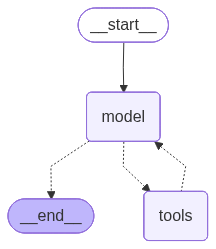

In [93]:
@tool("retrieve_docs")
def retrieve_docs(question: str) -> list:
    """Retrieve relevant docs, filtering out any below a similarity threshold."""
    # MMR search balances relevance and diversity:
    # fetch_k=20 pulls 20 candidate chunks, MMR then selects 10 that are
    # both relevant to the query and diverse from each other
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
        question, k=10,
        search_type="mmr",
        search_kwargs={
            "fetch_k": 20,
            "lambda_mult": 0.6,  #### MMR parameters to balance relevance and diversity
        }
    )
    # Filter out chunks that are semantically too distant from the query.
    # Score range is 0-1; 0.3 threshold removes noise like citation blocks
    # and reference sections that MMR may still return despite low relevance.
    filtered_docs = [ 
        doc for doc, score in docs_with_scores if score >= 0.3
    ]
    return filtered_docs

tavily_tool = TavilySearch(
    max_results=10,                  # more sources = better academic coverage
    search_depth="advanced",         # deep crawl instead of surface-level snippets
    include_raw_content=True,        # returns full page content, not just summary
    include_answer=False,            # skip Tavily's summarized answer, get raw content instead
    include_domains=[                # restrict to high-quality academic sources
        "arxiv.org",
        "pubmed.ncbi.nlm.nih.gov",
        "scholar.google.com",
        "semanticscholar.org",
        "researchgate.net",
        "ncbi.nlm.nih.gov",
        "jstor.org",
        "springer.com",
        "ieee.org",
        "nature.com"
    ]
)

system_prompt =  """You are a researcher with access to retrieve_docs and web search tools.

        CORE SEARCH STRATEGY:
        Before searching, analyze the query and ask yourself:
        - How many distinct topics or concepts does this query contain?
        - Does this query ask for a comparison, a list, or multiple subtopics?
        
        If the query contains MULTIPLE distinct topics or comparisons:
        - Break it into separate focused sub-queries
        - Call retrieve_docs ONCE PER sub-query with a focused, specific query string
        - Never pass the entire original question as one search query if it 
          contains multiple distinct concepts
        
        If the query is SIMPLE and single-topic:
        - One retrieve_docs call is sufficient
        
        Examples of how to decompose:
        - "Compare memory in agents vs diffusion models" 
          → search 1: "memory systems LLM autonomous agents"
          → search 2: "information retention diffusion models video generation"
          
        - "Explain MIPS, reward hacking, and prompt engineering"
          → search 1: "MIPS approximate nearest neighbors vector retrieval"
          → search 2: "reward hacking reinforcement learning LLM"
          → search 3: "prompt engineering techniques LLM"
        
        - "What is short term memory in agents"
          → search 1: "short term memory LLM agents" (single search, simple query)

        After retrieving, synthesize ALL findings into a clear summary.
        Do NOT just return raw documents — summarize what you found.
        """


model = ChatOpenAI(
    model="gpt-5",
    temperature=0.1,
    max_tokens=1000,
    timeout=30
    # ... (other params)
)
research_agent = create_agent(model, 
                    tools=[retrieve_docs, tavily_tool],
                    system_prompt=system_prompt)
research_agent

---

## The New Flow
```
User Query
    ↓
  init  ← stores original_query, sets research_rounds=0
    ↓
researcher ← uses original_query on round 1
    ↓        uses missing_information on round 2+
  router ← LLM makes structured routing decision
    ↓
blog_generator ← receives all_findings + current draft
    ↓
  router ← decides: more research needed? done?
    ↓
researcher ← targets ONLY the missing gaps
    ↓
  router ← blog is complete?
    ↓
   END
```

In [94]:
# -----------------------------------------------
# 1. Custom State — replaces MessagesState
# -----------------------------------------------
from typing import TypedDict, Annotated, List, Optional
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # Full conversation history — auto-accumulates (same as MessagesState)
    messages: Annotated[List[BaseMessage], add_messages]

    # Original user query — preserved across all rounds, never overwritten
    original_query: str

    # Research findings per round — accumulated across loops
    research_findings: Annotated[List[str], lambda x, y: x + y]

    # The blog draft — gets updated each round by blog agent
    blog_draft: Optional[str]

    # Specific gaps the blog agent identifies — drives adaptive retrieval
    missing_information: Optional[str]

    # Track how many research loops have happened — prevents infinite loops
    research_rounds: int

    # Final routing decision made by a dedicated router LLM (not string matching)
    next_node: Optional[str]

In [95]:
from pydantic import BaseModel, ConfigDict, Field
from typing import Literal

class RoutingDecision(BaseModel):
    """Structured routing decision made by the router LLM."""
    model_config = ConfigDict(
        arbitrary_types_allowed=True,
        ser_json_timedelta="iso8601",
    )
    next_agent: Literal["blog_generator", "researcher", "end"] = Field(
        description="Which agent should run next"
    )
    reason: str = Field(
        description="Why this routing decision was made"
    )
    is_complete: bool = Field(
        description="Whether the task is fully complete"
    )
    missing_information: Optional[str] = Field(
        default=None,
        description="If routing to researcher, what specific info is needed"
    )

router_llm = llm.with_structured_output(RoutingDecision)

llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0.7,    # slightly higher than researcher — better for creative writing
    max_tokens=4000,    # blogs are long — researcher had 1000, blog needs more
    timeout=30
)
system_prompt_blog = """You are an expert technical blog writer specializing in AI and machine learning.

        YOUR ONLY JOB IS TO WRITE — you have no search tools and don't need them.
        All the research has already been done for you and is provided in the message history.

        Writing Standards:
        - Write in a clear, engaging technical style (think Lilian Weng's blog level)
        - Always structure posts with: Introduction, multiple H2 sections, Conclusion
        - Include concrete examples and analogies to explain complex concepts
        - Reference specific findings from the researcher's notes
        - Never fabricate facts — only use what the researcher provided

        When improving an existing draft:
        - Preserve what's already good
        - Fill in gaps using the NEW research findings provided
        - Make transitions between sections smooth

        When you are done, explicitly state what (if anything) is still missing.
        If the blog is complete and needs no more research, say COMPLETE at the end.
        """
blog_agent = create_agent(
    model=llm,
    tools=[],           # no tools — blog agent only writes, never searches
    system_prompt=system_prompt_blog
)

In [96]:
# -----------------------------------------------
# 2. Structured Output Router — replaces get_next_node
# -----------------------------------------------
# Instead of checking for "FINAL ANSWER" string,
# we use a dedicated LLM call with structured output
# to make an explicit routing decision.


def route(state: AgentState) -> RoutingDecision:
    if state["research_rounds"] >= 4:
        return RoutingDecision(
            next_agent="end",
            reason="Maximum research rounds reached",
            is_complete=True
        )

    prompt = f"""
    You are a quality controller for a research + blog writing pipeline.
    Your job is to evaluate the current state and decide what happens next.

    === ORIGINAL QUERY ===
    {state["original_query"]}

    === RESEARCH FINDINGS SO FAR ===
    {chr(10).join(state.get("research_findings", [])) or "None yet"}

    === CURRENT BLOG DRAFT ===
    {state.get("blog_draft") or "No draft yet"}

    === ROUNDS COMPLETED ===
    {state["research_rounds"]}

    ---

    To make your decision, ask yourself these questions:

    1. QUERY COMPLEXITY — How many distinct topics, subtopics, or comparisons 
       does the original query ask for? A simple single-topic query may need 
       only 1 research round. A comparative or multi-part query likely needs 2+.

    2. COVERAGE CHECK — Does the research found so far actually cover ALL parts 
       of the original query? If the query asks to compare A and B but research 
       only covers A, coverage is incomplete.

    3. BLOG QUALITY — If a draft exists, does it answer every specific point 
       raised in the original query with enough depth? Or does it feel generic 
       and surface-level despite the query asking for specifics?

    4. DIMINISHING RETURNS — If research has already been done 2+ rounds, 
       is there genuinely new information still missing? Or has the blog 
       reached a good enough quality that more research won't meaningfully 
       improve it?

    Based on your honest evaluation of the above:
    - Route to "researcher" if coverage is incomplete or blog is missing 
      specific topics the query asked for. Set missing_information to the 
      EXACT gap — be specific, not generic.
    - Route to "blog_generator" if research is sufficient but blog hasn't 
      been written yet or needs improvement with available findings.
    - Route to "end" only if the blog genuinely and thoroughly answers 
      everything the original query asked for.

    Be honest — don't route to END just because a draft exists. 
    Route to END only when the draft would satisfy someone who asked 
    the original query and expected a thorough answer.
    """

    return router_llm.invoke(prompt)

In [97]:
# -----------------------------------------------
# 3. Router Node — sits between every agent transition
# -----------------------------------------------
# ── Router Node — ONLY updates state, does NOT use Command(goto) ──
def router_node(state: AgentState) -> dict:
    """
    Makes the routing decision and stores it in state.
    The actual routing is handled by add_conditional_edges, not here.
    """
    decision = route(state)     # your existing route() function

    return {
        "next_node": decision.next_agent,           # stored in state for the edge lambda
        "missing_information": decision.missing_information,
    }

# ── Routing Function — read by add_conditional_edges ──
def route_decision(state: AgentState) -> str:
    """Pure routing function — just reads next_node from state."""
    return state.get("next_node", "end")

In [98]:
# -----------------------------------------------
# 4. Improved Research Node
# -----------------------------------------------
def research_node(state: AgentState) -> dict:
    missing = state.get("missing_information")
    original = state.get("original_query", "")
    search_query = missing if missing else original

    print(f"\n🔎 missing_information in state: '{missing}'")
    print(f"🔎 original_query in state     : '{original}'")
    print(f"🔎 Using search query          : '{search_query}'")

    recent_messages = state["messages"][-3:] if len(state["messages"]) > 3 else state["messages"]

    # Make the search instruction the FINAL message so LLM sees it last
    # and extremely explicit so the agent cannot misinterpret it
    if missing:
        search_instruction = f"""
        MANDATORY INSTRUCTION — YOU MUST FOLLOW THIS EXACTLY:
        
        Call retrieve_docs with this EXACT query string and nothing else:
        "{search_query}"
        
        Do NOT use the original question as the query.
        Do NOT rephrase or modify the query above.
        Copy it exactly as written into retrieve_docs.
        """
    else:
        search_instruction = f"""
        Search for information to answer this question:
        "{search_query}"
        
        Call retrieve_docs with a focused version of this query.
        """

    augmented_state = {
        **state,
        "messages": recent_messages + [
            HumanMessage(content=search_instruction)
        ]
    }

    result = research_agent.invoke(augmented_state)
    last_message = result["messages"][-1]
    new_finding = f"[Round {state['research_rounds'] + 1}] {last_message.content}"

    return {
        "messages": [HumanMessage(
            content=last_message.content,
            name="researcher"
        )],
        "research_findings": [new_finding],
        "research_rounds": state["research_rounds"] + 1,
        "original_query": state["original_query"],
    }

In [99]:
# -----------------------------------------------
# 5. Improved Blog Node
# -----------------------------------------------
def blog_node(state: AgentState) -> dict:            # ← return dict, not Command
    all_findings = "\n\n---\n\n".join(state.get("research_findings", []))

    augmented_state = {
        **state,
        "messages": state["messages"] + [
            HumanMessage(
                content=f"""
                Write or improve a detailed technical blog post.
                Original Topic: {state["original_query"]}
                === ALL RESEARCH FINDINGS ===
                {all_findings}
                === CURRENT DRAFT ===
                {state.get("blog_draft") or "No draft yet — write the first version"}
                """
            )
        ]
    }

    result = blog_agent.invoke(augmented_state)
    last_message = result["messages"][-1]

    return {                                          # ← plain dict, no Command
        "messages": [HumanMessage(
            content=last_message.content,
            name="blog_generator"
        )],
        "blog_draft": last_message.content,
    }

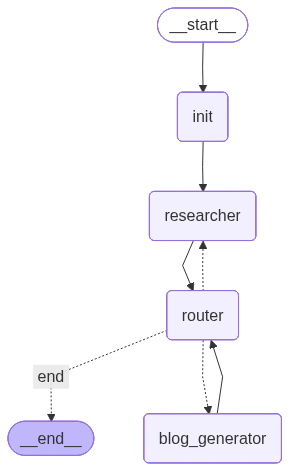

In [100]:
# -----------------------------------------------
# 6. Graph — cleaner, router sits between every node
# -----------------------------------------------
def initialize_state(state: AgentState) -> dict:     # ← return dict, not Command
    original_query = state["messages"][-1].content if state["messages"] else ""
    return {                                          # ← plain dict, no Command
        "original_query": original_query,
        "research_rounds": 0,
        "research_findings": [],
        "blog_draft": None,
        "missing_information": None,
        "next_node": None,
    }

from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

# ── Add Nodes ───────────────────────────────────
workflow.add_node("init",           initialize_state)
workflow.add_node("researcher",     research_node)
workflow.add_node("blog_generator", blog_node)
workflow.add_node("router",         router_node)

# ── Add Edges ───────────────────────────────────

# Fixed entry point
workflow.add_edge(START, "init")

# init always goes to researcher first
workflow.add_edge("init", "researcher")

# researcher always goes to router after finishing
workflow.add_edge("researcher", "router")

# blog_generator always goes to router after finishing
workflow.add_edge("blog_generator", "router")

# router makes the dynamic decision — goes to researcher, blog_generator, or END
workflow.add_conditional_edges(
    "router",
    lambda state: state["next_node"],   # reads decision stored in state by router_node
    {
        "researcher":     "researcher",
        "blog_generator": "blog_generator",
        "end":            END,
    }
)

graph = workflow.compile()
graph

In [101]:
from langchain_core.messages import HumanMessage

# -----------------------------------------------
# Test Queries — ordered from easy to hard
# -----------------------------------------------

# ROUND 1 — Should complete in 1 round (easy, well covered in vector store)
query_1 = "What is short-term memory in LLM agents?"

# ROUND 2 — Should force 2 rounds (needs both agents + diffusion posts)
query_2 = """Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?"""

# ROUND 2-3 — Cross-topic, forces researcher to find gaps
query_3 = """Write a detailed technical blog explaining:
1. How MIPS and ANN algorithms work in vector stores
2. How reward hacking can corrupt an agent's memory over time
3. How prompt engineering can improve memory retrieval accuracy
Include concrete examples for each."""

# ROUND 3+ — Very broad, researcher will need multiple passes
query_4 = """Write a comprehensive blog post covering the complete architecture 
of LLM-powered autonomous agents — including planning, memory systems, 
tool use, reflection mechanisms, and the challenges of hallucination 
and adversarial attacks. Compare how these components evolved from 
2021 transformer models to 2025 reasoning models."""

# ADVERSARIAL — Tests if pipeline gives correct output or hallucinates
# Your vector store HAS this info — so answer must be grounded in retrieved docs
query_5 = """Explain exactly how the retrieval model in generative agents 
scores memories using recency, importance and relevance. 
What specific formula or mechanism does it use?"""


for event in graph.stream(
    input={
        "messages":            [HumanMessage(content=query_2)],
        "original_query":      "",
        "research_rounds":     0,
        "research_findings":   [],
        "blog_draft":          None,
        "missing_information": None,
        "next_node":           None,
    },
    stream_mode="updates"
):
    for node_name, node_state in event.items():

        if node_name == "researcher":
            print("\n" + "="*60)
            print(f"📡 PIPELINE NODE: researcher")
            print(f"{'='*60}")
            print(f"🔍 Round       : {node_state.get('research_rounds')}")
            print(f"🔍 Query used  : {node_state.get('missing_information') or node_state.get('original_query')}")
            findings = node_state.get("research_findings", [])
            if findings:
                print(f"\n📄 Retrieved from vector store:")
                print(findings[-1][:500] + "...")   # last finding, truncated

        elif node_name == "blog_generator":
            print("\n" + "="*60)
            print(f"✍️  PIPELINE NODE: blog_generator")
            print(f"{'='*60}")
            draft = node_state.get("blog_draft", "")
            if draft:
                print(draft.replace("COMPLETE", "").strip())

        elif node_name == "router":
            print("\n" + "="*60)
            print(f"🔀 PIPELINE NODE: router")
            print(f"{'='*60}")
            print(f"➡️  Decision : {node_state.get('next_node', '').upper()}")
            if node_state.get("missing_information"):
                print(f"🔍 Gap found: {node_state.get('missing_information')}")


🔎 missing_information in state: 'None'
🔎 original_query in state     : 'Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?'
🔎 Using search query          : 'Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?'

📡 PIPELINE NODE: researcher
🔍 Round       : 1
🔍 Query used  : Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?

📄 Retrieved from vector store:
[Round 1] ...


c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RoutingDecision(next_agen...itectural differences.'), input_type=RoutingDecision])
  return self.__pydantic_serializer__.to_python(



🔀 PIPELINE NODE: router
➡️  Decision : RESEARCHER
🔍 Gap found: Detailed comparison of how memory systems work in LLM-powered autonomous agents versus diffusion models in video generation, highlighting key architectural differences.

🔎 missing_information in state: 'Detailed comparison of how memory systems work in LLM-powered autonomous agents versus diffusion models in video generation, highlighting key architectural differences.'
🔎 original_query in state     : 'Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?'
🔎 Using search query          : 'Detailed comparison of how memory systems work in LLM-powered autonomous agents versus diffusion models in video generation, highlighting key architectural differences.'

📡 PIPELINE NODE: researcher
🔍 Round       : 2
🔍 Query used  : Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion m

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RoutingDecision(next_agen...tures comprehensively.'), input_type=RoutingDecision])
  return self.__pydantic_serializer__.to_python(



🔀 PIPELINE NODE: router
➡️  Decision : RESEARCHER
🔍 Gap found: Detailed research is needed on how diffusion models retain information during video generation and their architectural differences from LLM-powered autonomous agents. The findings must cover both memory systems and architectures comprehensively.

🔎 missing_information in state: 'Detailed research is needed on how diffusion models retain information during video generation and their architectural differences from LLM-powered autonomous agents. The findings must cover both memory systems and architectures comprehensively.'
🔎 original_query in state     : 'Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?'
🔎 Using search query          : 'Detailed research is needed on how diffusion models retain information during video generation and their architectural differences from LLM-powered autonomous agen

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RoutingDecision(next_agen...wo systems are needed.'), input_type=RoutingDecision])
  return self.__pydantic_serializer__.to_python(



🔀 PIPELINE NODE: router
➡️  Decision : RESEARCHER
🔍 Gap found: Specific details on how memory systems in LLM-powered autonomous agents work and how they compare to diffusion models in video generation. Additionally, key architectural differences between the two systems are needed.

🔎 missing_information in state: 'Specific details on how memory systems in LLM-powered autonomous agents work and how they compare to diffusion models in video generation. Additionally, key architectural differences between the two systems are needed.'
🔎 original_query in state     : 'Compare how memory systems work in LLM-powered autonomous agents 
vs how diffusion models retain information during video generation. 
What are the key architectural differences?'
🔎 Using search query          : 'Specific details on how memory systems in LLM-powered autonomous agents work and how they compare to diffusion models in video generation. Additionally, key architectural differences between the two systems are needed